# 2017 311 Service

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

They represent all service requests such as abandoned automobiles, parking meter repair and bulk trash pickup. Requests are received by the Office of Unified Communications (OUC) through the Mayor's Call Center (311), citizens web intake at https://311.dc.gov, electronic and US mail service or via other methods of communication. The Office of Unified Communications (OUC) oversees the designated call center for all 311 calls and for all District 911 calls.

https://opendata.dc.gov/datasets/DCGIS::311-city-service-requests-in-2017/about

# Data exploration

In [2]:
# load data
df = pd.read_csv("All_Service_Requests_-_2017.csv")
# check data
df.head()

,X,Y,SERVICEREQUESTID,STREETADDRESS,CITY,STATE,ZIPCODE,WARD,SERVICECODE,SERVICECODEDESCRIPTION,...,XCOORD,YCOORD,LATITUDE,LONGITUDE,MARADDRESSREPOSITORYID,GLOBALID,CREATED,EDITED,OBJECTID,SE_ANNO_CAD_DATA
0,401676.16,136732.19,17-00611599,"1630 GALES STREET NE,WASHINGTON,DC,USA,20002",WASHINGTON,DC,20002.0,Ward 6,S0031,Bulk Collection,...,401676.16,136732.19,38.898439,-76.980677,59017.0,{9A67F2AA-D070-22AA-E053-532F520A924B},NaN,NaN,7742223,NaN
1,397910.12,143336.50,17-00284047,"5600 - 5699 BLOCK OF 8TH STREET NW,WASHINGTON,...",WASHINGTON,DC,20011.0,Ward 4,EMNPV,Emergency No-Parking Verification,...,397910.12,143336.50,38.957932,-77.024112,802369.0,{9A67F2AA-E07E-22AA-E053-532F520A924B},NaN,NaN,7746333,NaN
2,401614.04,134697.88,17-00284117,"1613 H STREET SE,WASHINGTON,DC,USA,20003",WASHINGTON,DC,20003.0,Ward 6,S04TP,Tree Planting,...,401614.04,134697.88,38.880114,-76.981398,59797.0,{9A67F2AA-E07F-22AA-E053-532F520A924B},NaN,NaN,7746334,NaN
3,397137.95,141925.79,17-00284127,"4500 14TH STREET NW,WASHINGTON,DC,USA,20011",WASHINGTON,DC,20011.0,Ward 4,S0441,Trash Collection - Missed,...,397137.95,141925.79,38.945222,-77.033015,255486.0,{9A67F2AA-E080-22AA-E053-532F520A924B},NaN,NaN,7746335,NaN
4,400309.39,129166.20,17-00284131,"672 BRANDYWINE STREET SE,WASHINGTON,DC,USA,20032",WASHINGTON,DC,20032.0,Ward 8,S0181,Illegal Dumping,...,400309.39,129166.20,38.830283,-76.996437,804.0,{9A67F2AA-E081-22AA-E053-532F520A924B},NaN,NaN,7746336,NaN


In [6]:
# basic exploration
print("rows, cols:", df.shape)

# column types
pd.DataFrame({"dtype": df.dtypes}).T

# missing values (top 15)
df.isna().sum().sort_values(ascending=False).head(15)

# numeric summary
num_cols = df.select_dtypes(include="number")
num_cols.describe().T

# categorical summary (top 15 by distinct count)
cat_cols = df.select_dtypes(include="object")
cat_cols.nunique().sort_values(ascending=False).head(15)

rows, cols: (311521, 36)


/tmp/ipykernel_5405/205506763.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object")


SERVICEREQUESTID              311521
GLOBALID                      311521
SERVICEORDERDATE              308044
STREETADDRESS                 101721
DETAILS                        74512
SERVICECODEDESCRIPTION           120
SERVICECODE                      119
SERVICETYPECODEDESCRIPTION        27
SERVICEORDERSTATUS                12
ORGANIZATIONACRONYM               12
WARD                               9
PRIORITY                           5
CITY                               1
STATE                              1
dtype: int64

In [10]:
# -----------------------------
# 1) Normalize column names
# -----------------------------
df.columns = [c.strip() for c in df.columns]
colmap = {c: c.upper().replace(" ", "_") for c in df.columns}
df = df.rename(columns=colmap)

print("Example columns after normalization:")
print(df.columns[:30])

# -----------------------------
# 1.1) Helper: find a column by candidate names
# -----------------------------
def find_col(cols, candidates):
    """Return the first matching column name from a list of candidates."""
    for cand in candidates:
        if cand in cols:
            return cand
    return None

cols = set(df.columns)

created_col = find_col(cols, ["CREATED_DATE", "CREATEDDATE", "DATE_CREATED", "REQUESTED_DATE", "REQUESTEDDATE"])
closed_col  = find_col(cols, ["CLOSED_DATE", "CLOSEDDATE", "DATE_CLOSED", "RESOLVED_DATE", "RESOLVEDDATE"])
type_col    = find_col(cols, ["SERVICE_TYPE", "REQUESTTYPE", "REQUEST_TYPE", "SERVICECODEDESCRIPTION", "SERVICE_NAME"])
ward_col    = find_col(cols, ["WARD", "WARD_ID", "WARDID"])
lat_col     = find_col(cols, ["LATITUDE", "LAT"])
lon_col     = find_col(cols, ["LONGITUDE", "LON", "LONG"])

print("Detected columns:")
print(" created_col:", created_col)
print(" closed_col :", closed_col)
print(" type_col   :", type_col)
print(" ward_col   :", ward_col)
print(" lat/lon    :", lat_col, lon_col)


Example columns after normalization:
Index(['X', 'Y', 'SERVICEREQUESTID', 'STREETADDRESS', 'CITY', 'STATE',
       'ZIPCODE', 'WARD', 'SERVICECODE', 'SERVICECODEDESCRIPTION',
       'SERVICETYPECODEDESCRIPTION', 'ORGANIZATIONACRONYM', 'SERVICECALLCOUNT',
       'ADDDATE', 'RESOLUTIONDATE', 'SERVICEDUEDATE', 'SERVICEORDERDATE',
       'INSPECTIONFLAG', 'INSPECTIONDATE', 'INSPECTORNAME',
       'SERVICEORDERSTATUS', 'STATUS_CODE', 'DETAILS', 'PRIORITY', 'XCOORD',
       'YCOORD', 'LATITUDE', 'LONGITUDE', 'MARADDRESSREPOSITORYID',
       'GLOBALID'],
      dtype='str')
Detected columns:
 created_col: None
 closed_col : None
 type_col   : SERVICECODEDESCRIPTION
 ward_col   : WARD
 lat/lon    : LATITUDE LONGITUDE


In [4]:
# make new column for due time and actual response time (hours)
for col in ["ADDDATE", "SERVICEDUEDATE", "RESOLUTIONDATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["DUE_TIME_HOURS"] = (df["SERVICEDUEDATE"] - df["ADDDATE"]).dt.total_seconds() / 3600
df["RESPONSE_TIME_HOURS"] = (df["RESOLUTIONDATE"] - df["ADDDATE"]).dt.total_seconds() / 3600

df[["ADDDATE", "SERVICEDUEDATE", "RESOLUTIONDATE", "DUE_TIME_HOURS", "RESPONSE_TIME_HOURS"]].head()

,ADDDATE,SERVICEDUEDATE,RESOLUTIONDATE,DUE_TIME_HOURS,RESPONSE_TIME_HOURS
0,2017-10-30 18:41:43+00:00,2017-11-20 19:41:00+00:00,2017-11-06 13:38:00+00:00,504.988056,162.938056
1,2017-05-31 22:44:32+00:00,2017-06-01 21:00:00+00:00,2017-06-01 00:02:29+00:00,22.257778,1.299167
2,2017-05-31 23:51:45+00:00,2020-04-14 21:00:00+00:00,2017-06-13 13:18:09+00:00,25173.137500,301.440000
3,2017-06-01 00:05:53+00:00,2017-06-02 21:00:00+00:00,2017-06-05 11:23:21+00:00,44.901944,107.291111
4,2017-06-01 00:09:29+00:00,2017-06-07 21:00:00+00:00,2017-06-02 12:11:09+00:00,164.841944,36.027778


## Distribution of response time

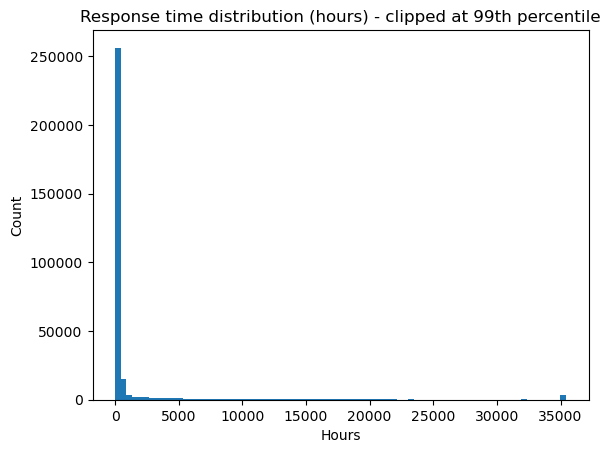

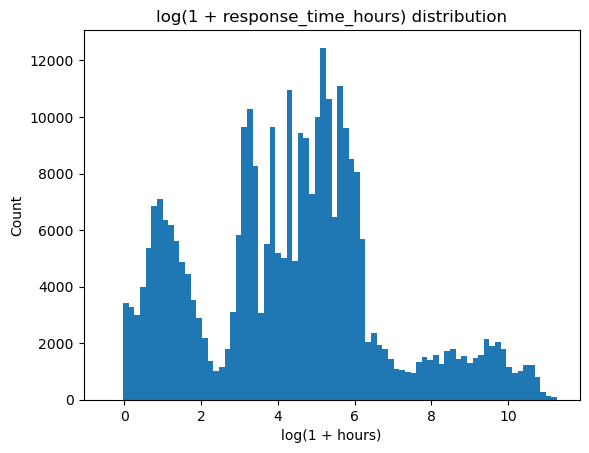

In [12]:
rt = df["RESPONSE_TIME_HOURS"].dropna()

# Clip extreme tail for readability
rt_clip = rt.clip(upper=rt.quantile(0.99))

plt.figure()
plt.hist(rt_clip, bins=80)
plt.title("Response time distribution (hours) - clipped at 99th percentile")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(np.log1p(rt), bins=80)
plt.title("log(1 + response_time_hours) distribution")
plt.xlabel("log(1 + hours)")
plt.ylabel("Count")
plt.show()


most cases resolve relatively quickly, there’s a wide spread of “typical” response times, and a small but meaningful fraction takes much longer.

## Due time vs response time + SLA violation (overdue)

Overall overdue rate: 0.16196018887972238


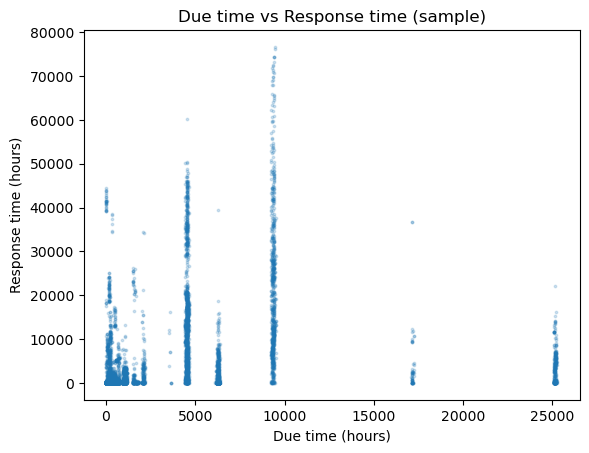

Overall on-time rate (among records with both due & response): 0.8375668836562421


In [13]:
# Overdue definition: resolved after due date (needs both due + resolution)
df["OVERDUE"] = ((df["RESOLUTIONDATE"] > df["SERVICEDUEDATE"]) &
                df["RESOLUTIONDATE"].notna() &
                df["SERVICEDUEDATE"].notna()).astype(int)

# How late (hours) among overdue cases
df["LATE_HOURS"] = (df["RESOLUTIONDATE"] - df["SERVICEDUEDATE"]).dt.total_seconds() / 3600
df.loc[df["OVERDUE"] == 0, "LATE_HOURS"] = 0

print("Overall overdue rate:", df["OVERDUE"].mean())

# Scatter: due vs response (sample for speed)
tmp = df.dropna(subset=["DUE_TIME_HOURS", "RESPONSE_TIME_HOURS"]).sample(
    min(30000, df.dropna(subset=["DUE_TIME_HOURS","RESPONSE_TIME_HOURS"]).shape[0]),
    random_state=42
)

plt.figure()
plt.scatter(tmp["DUE_TIME_HOURS"], tmp["RESPONSE_TIME_HOURS"], s=3, alpha=0.2)
plt.title("Due time vs Response time (sample)")
plt.xlabel("Due time (hours)")
plt.ylabel("Response time (hours)")
plt.show()

# How often response time <= due time (on-time)
df["ON_TIME"] = ((df["RESPONSE_TIME_HOURS"] <= df["DUE_TIME_HOURS"]) &
                 df["RESPONSE_TIME_HOURS"].notna() &
                 df["DUE_TIME_HOURS"].notna()).astype(int)

print("Overall on-time rate (among records with both due & response):",
      df.loc[df["RESPONSE_TIME_HOURS"].notna() & df["DUE_TIME_HOURS"].notna(), "ON_TIME"].mean())


## Response time by different factors

### By service type: median response time, volume, overdue rate (Top N)

,n,median_rt,p90_rt,overdue_rate,on_time_rate
SERVICECODEDESCRIPTION,,,,,
Sidewalk Repair,4301,12631.667500,39879.505500,0.682632,0.297140
Roadway Signs,15624,9481.865556,34485.711556,0.660138,0.339798
Tree Planting,3562,2704.749444,10038.992500,0.015160,0.984840
Tree Pruning,4170,693.002639,6040.837472,0.087290,0.912710
Rodent Inspection and Treatment,5311,452.658056,1342.325278,0.446055,0.553945
Bulk Collection,50626,255.226389,449.324556,0.039031,0.960870
Alley Cleaning,7864,242.936389,2112.668000,0.152085,0.847787
Street Cleaning,5451,232.499444,2155.824167,0.140892,0.859108
Traffic Signal Issue,3047,209.781944,504.242778,0.971119,0.028553


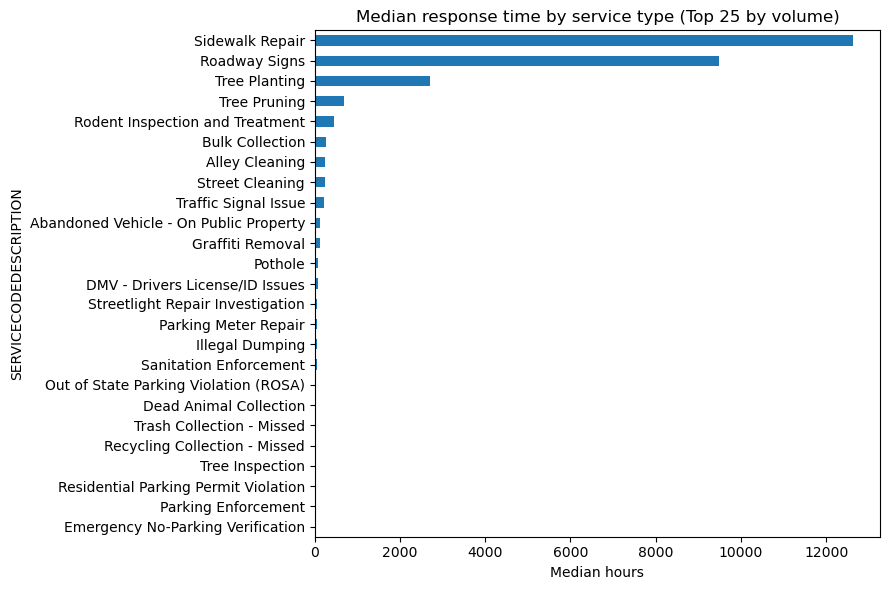

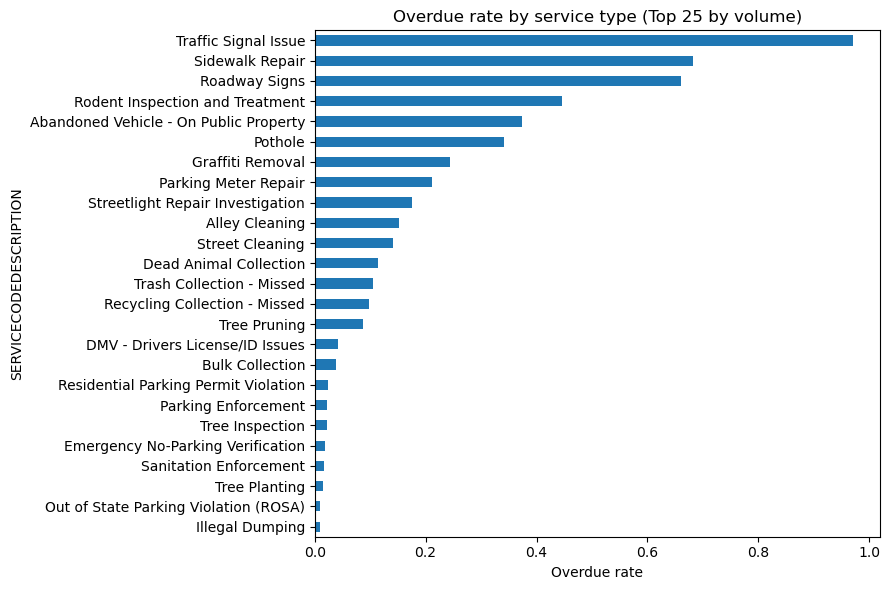

In [14]:
TOPN = 25
type_col = "SERVICECODEDESCRIPTION"

# Focus on types with enough volume
type_counts = df[type_col].value_counts()
top_types = type_counts.head(TOPN).index

sub = df[df[type_col].isin(top_types)].copy()

type_summary = sub.groupby(type_col).agg(
    n=("SERVICEREQUESTID", "size"),
    median_rt=("RESPONSE_TIME_HOURS", "median"),
    p90_rt=("RESPONSE_TIME_HOURS", lambda x: x.dropna().quantile(0.90) if x.notna().any() else np.nan),
    overdue_rate=("OVERDUE", "mean"),
    on_time_rate=("ON_TIME", "mean"),
).sort_values("median_rt", ascending=False)

display(type_summary)

# Plot: median response time (top types)
plt.figure(figsize=(9, 6))
type_summary["median_rt"].sort_values().plot(kind="barh")
plt.title(f"Median response time by service type (Top {TOPN} by volume)")
plt.xlabel("Median hours")
plt.tight_layout()
plt.show()

# Plot: overdue rate
plt.figure(figsize=(9, 6))
type_summary["overdue_rate"].sort_values().plot(kind="barh")
plt.title(f"Overdue rate by service type (Top {TOPN} by volume)")
plt.xlabel("Overdue rate")
plt.tight_layout()
plt.show()


### By ward: response time + overdue rate + request volume

,n,median_rt,p90_rt,overdue_rate
WARD,,,,
Ward 7,33888,134.555694,813.379417,0.136745
Ward 8,23489,118.485972,764.086694,0.137639
Ward 4,42082,116.391111,4198.445722,0.143007
Null,2943,112.646944,11923.977889,0.369691
Ward 5,42369,97.525833,1702.943444,0.136066
Ward 3,29675,94.054167,6749.204111,0.207211
Ward 1,36015,71.665417,2590.237083,0.146328
Ward 6,49973,63.821528,932.335694,0.147560
Ward 2,51087,56.869167,3694.005722,0.213812


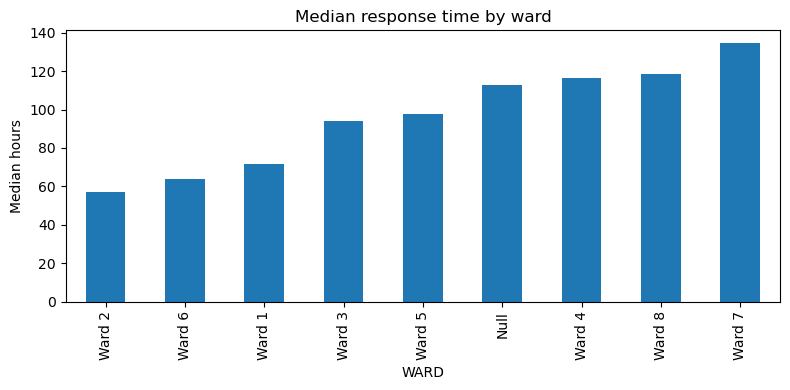

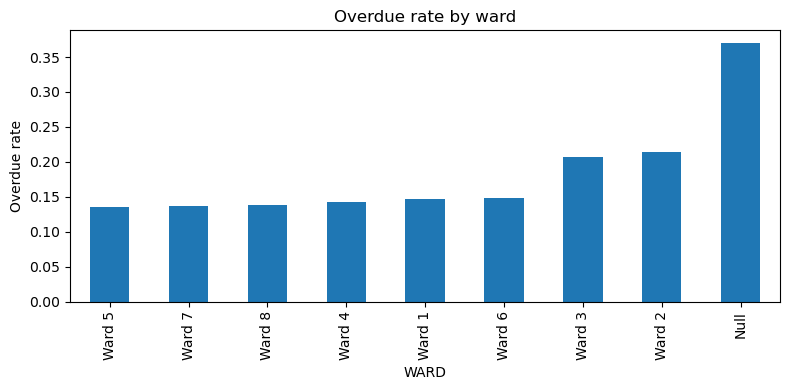

In [15]:
ward_col = "WARD"

ward_summary = df.groupby(ward_col).agg(
    n=("SERVICEREQUESTID", "size"),
    median_rt=("RESPONSE_TIME_HOURS", "median"),
    p90_rt=("RESPONSE_TIME_HOURS", lambda x: x.dropna().quantile(0.90) if x.notna().any() else np.nan),
    overdue_rate=("OVERDUE", "mean"),
).sort_values("median_rt", ascending=False)

display(ward_summary)

plt.figure(figsize=(8, 4))
ward_summary["median_rt"].sort_values().plot(kind="bar")
plt.title("Median response time by ward")
plt.ylabel("Median hours")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
ward_summary["overdue_rate"].sort_values().plot(kind="bar")
plt.title("Overdue rate by ward")
plt.ylabel("Overdue rate")
plt.tight_layout()
plt.show()


### Seasonality: month trend (volume + median response time)

/tmp/ipykernel_5405/314111760.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["MONTH"] = df["ADDDATE"].dt.to_period("M").astype(str)


,n,median_rt,overdue_rate
MONTH,,,
2017-01,22727,90.875417,0.125138
2017-02,21028,86.948472,0.140574
2017-03,24336,77.320000,0.171228
2017-04,24886,90.883889,0.157599
2017-05,27120,76.248889,0.160619
2017-06,29152,94.945833,0.185888
2017-07,29367,87.518194,0.152756
2017-08,30732,87.994583,0.134908
2017-09,27720,96.770556,0.156241


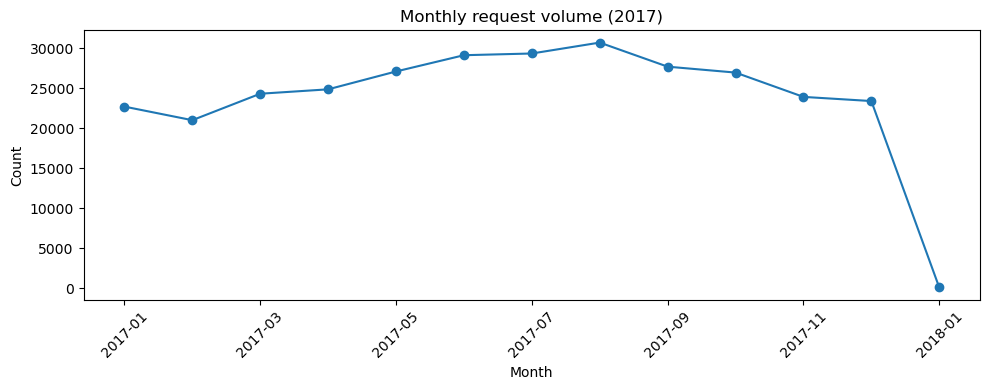

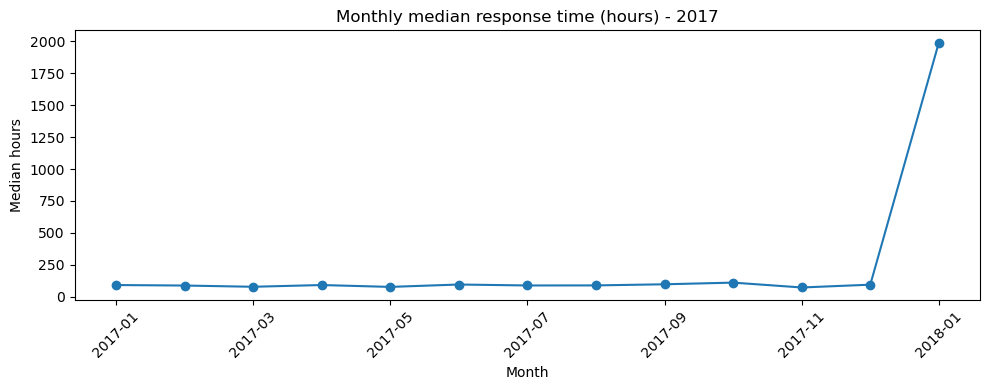

In [16]:
df["MONTH"] = df["ADDDATE"].dt.to_period("M").astype(str)
df["DOW"] = df["ADDDATE"].dt.day_name()

monthly = df.groupby("MONTH").agg(
    n=("SERVICEREQUESTID", "size"),
    median_rt=("RESPONSE_TIME_HOURS", "median"),
    overdue_rate=("OVERDUE", "mean")
)

display(monthly)

plt.figure(figsize=(10, 4))
monthly["n"].plot(kind="line", marker="o")
plt.title("Monthly request volume (2017)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
monthly["median_rt"].plot(kind="line", marker="o")
plt.title("Monthly median response time (hours) - 2017")
plt.xlabel("Month")
plt.ylabel("Median hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Pothole

### identify pothole-related requests + basic trend

Total pothole requests: 6947


MONTH
2017-01     887
2017-02     759
2017-03     753
2017-04    1326
2017-05     772
2017-06     474
2017-07     325
2017-08     461
2017-09     436
2017-10     245
2017-11     223
2017-12     286
2018-01       0
Name: IS_POTHOLE, dtype: int64

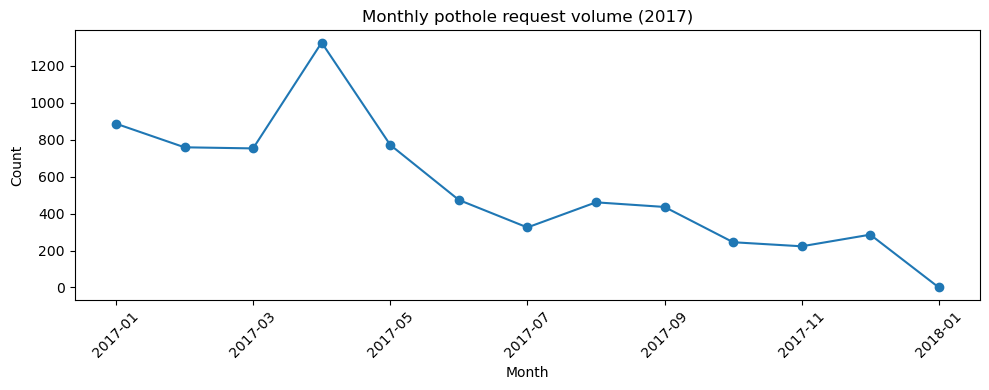

In [17]:
# Keyword-based tagging (you can expand keywords after inspecting type values)
df["IS_POTHOLE"] = df["SERVICECODEDESCRIPTION"].astype(str).str.contains("pothole", case=False, na=False).astype(int)

print("Total pothole requests:", df["IS_POTHOLE"].sum())

# Monthly pothole volume
pothole_monthly = df.groupby("MONTH")["IS_POTHOLE"].sum()
display(pothole_monthly)

plt.figure(figsize=(10, 4))
pothole_monthly.plot(kind="line", marker="o")
plt.title("Monthly pothole request volume (2017)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Challenge:** how to download the weather data?
https://www.ncei.noaa.gov/cdo-web/customoptions

## Service type exploration

rare category share (<=10): 0.1833


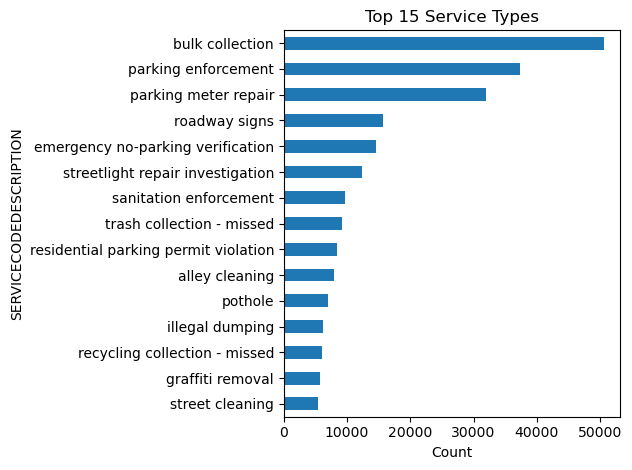

In [7]:
# service type exploration (for clustering)
service_cols = [
    "SERVICECODEDESCRIPTION",
    "SERVICECODE",
    "SERVICETYPECODEDESCRIPTION",
    "SERVICETYPECODE",
]
service_cols = [c for c in service_cols if c in df.columns]

# basic counts + missing
svc_summary = pd.DataFrame(
    {
        "missing": df[service_cols].isna().sum(),
        "unique": df[service_cols].nunique(),
    }
)
svc_summary

# clean a primary service-type feature
service_type = (
    df.get("SERVICECODEDESCRIPTION", pd.Series(index=df.index, dtype="string"))
    .astype("string")
    .str.strip()
    .str.lower()
    .fillna("unknown")
)

# top categories
service_type.value_counts().head(20)

# share of rare categories (<=10 occurrences)
rare_share = (service_type.value_counts() <= 10).mean()
print("rare category share (<=10):", round(rare_share, 4))

# plot top 15
service_type.value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Service Types")
plt.xlabel("Count")
plt.tight_layout()

In [8]:
# address exploration
addr_col = "STREETADDRESS" if "STREETADDRESS" in df.columns else None
if addr_col is None:
    print("No STREETADDRESS column found")
else:
    addr = (
        df[addr_col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .fillna("unknown")
    )

    # missing/empty
    missing_addr = (addr.eq("unknown") | addr.eq("")).mean()
    print("missing/empty share:", round(missing_addr, 4))

    # length summary
    addr.str.len().describe()

    # example addresses
    addr.value_counts().head(15)

    # simple parsing: house number + street name + unit/apt (best-effort)
    # pattern: number + street + optional unit suffix
    addr_parts = addr.str.extract(
        r"^(?P<number>\d+[A-Za-z]?)\s+(?P<street>[^,]+?)(?:\s+(?P<unit>(Apt|Unit|#)\s*[^,]+))?$"
    )

    # parse success rate
    parse_rate = addr_parts["street"].notna().mean()
    print("parse success rate:", round(parse_rate, 4))

    # top streets (from parsed)
    addr_parts["street"].str.strip().str.upper().value_counts().head(20)

    # if ZIP exists elsewhere, show how often addresses include a ZIP-like pattern
    zip_like = addr.str.contains(r"\b\d{5}\b", regex=True, na=False).mean()
    print("ZIP-like pattern in address:", round(zip_like, 4))

missing/empty share: 0.0
parse success rate: 0.0033
ZIP-like pattern in address: 0.7837


Top 2 service types: ['bulk collection', 'parking enforcement']


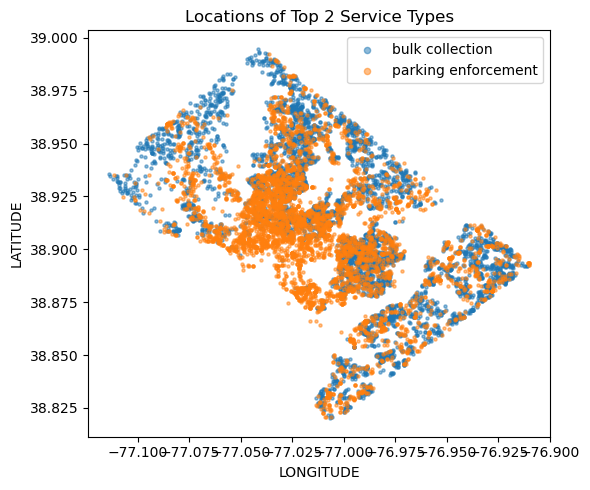

In [9]:
# location of top 2 service types
# determine top 2 service types from cleaned labels
try:
    service_type
except NameError:
    service_type = (
        df.get("SERVICECODEDESCRIPTION", pd.Series(index=df.index, dtype="string"))
        .astype("string")
        .str.strip()
        .str.lower()
        .fillna("unknown")
    )

# top 2 service types
_top2 = service_type.value_counts().head(2).index.tolist()
print("Top 2 service types:", _top2)

# try to find latitude/longitude columns
lat_col = next((c for c in ["LATITUDE", "Lat", "lat"] if c in df.columns), None)
lon_col = next((c for c in ["LONGITUDE", "Lon", "lon", "LON"] if c in df.columns), None)

if lat_col and lon_col:
    mask = service_type.isin(_top2)
    plot_df = df.loc[mask, [lat_col, lon_col]].copy()
    plot_df["service_type"] = service_type.loc[mask].to_numpy()

    # downsample for readability
    plot_df = plot_df.dropna(subset=[lat_col, lon_col])
    if plot_df.empty:
        print("No coordinates available for the top 2 service types.")
    else:
        samples = []
        for name, g in plot_df.groupby("service_type"):
            samples.append(g.sample(min(len(g), 5000), random_state=42))
        plot_df = pd.concat(samples, ignore_index=True)

        plt.figure(figsize=(6, 5))
        for name, g in plot_df.groupby("service_type"):
            plt.scatter(g[lon_col], g[lat_col], s=5, alpha=0.5, label=name)
        plt.title("Locations of Top 2 Service Types")
        plt.xlabel(lon_col)
        plt.ylabel(lat_col)
        plt.legend(markerscale=2)
        plt.tight_layout()
elif "WARD" in df.columns:
    ward_counts = (
        df.loc[service_type.isin(_top2)]
        .groupby([service_type, "WARD"])
        .size()
        .unstack(0)
        .fillna(0)
    )
    ward_counts.plot(kind="bar", figsize=(7, 4))
    plt.title("Top 2 Service Types by Ward")
    plt.xlabel("Ward")
    plt.ylabel("Count")
    plt.tight_layout()
else:
    print("No LAT/LON or WARD columns found to plot locations.")

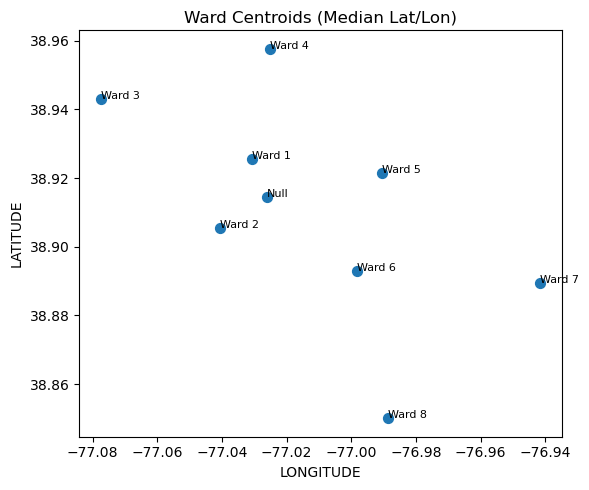

In [15]:
# relate latitude/longitude to ward
lat_col = next((c for c in ["LATITUDE", "Lat", "lat"] if c in df.columns), None)
lon_col = next((c for c in ["LONGITUDE", "Lon", "lon", "LON"] if c in df.columns), None)

if lat_col and lon_col and "WARD" in df.columns:
    ward_geo = (
        df[["WARD", lat_col, lon_col]]
        .dropna()
        .groupby("WARD")
        .agg(
            count=(lat_col, "size"),
            lat_median=(lat_col, "median"),
            lon_median=(lon_col, "median"),
            lat_min=(lat_col, "min"),
            lat_max=(lat_col, "max"),
            lon_min=(lon_col, "min"),
            lon_max=(lon_col, "max"),
        )
        .sort_values("count", ascending=False)
    )
    ward_geo

    # scatter of ward centroids
    plt.figure(figsize=(6, 5))
    plt.scatter(ward_geo["lon_median"], ward_geo["lat_median"], s=50)
    for ward, row in ward_geo.iterrows():
        plt.text(row["lon_median"], row["lat_median"], str(ward), fontsize=8)
    plt.title("Ward Centroids (Median Lat/Lon)")
    plt.xlabel(lon_col)
    plt.ylabel(lat_col)
    plt.tight_layout()

    # lat/lon spread per ward (how large each ward appears)
    ward_geo[["lat_min", "lat_max", "lon_min", "lon_max"]]
else:
    print("WARD and/or LAT/LON columns not found.")

### Service type construction

In [20]:
import numpy as np
import pandas as pd

type_col = "SERVICECODEDESCRIPTION"

# Basic time features
df["MONTH"] = df["ADDDATE"].dt.to_period("M").astype(str)
df["WEEKEND"] = df["ADDDATE"].dt.dayofweek.isin([5, 6]).astype(int)

# Overdue + late hours
df["OVERDUE"] = ((df["RESOLUTIONDATE"] > df["SERVICEDUEDATE"]) &
                 df["RESOLUTIONDATE"].notna() & df["SERVICEDUEDATE"].notna()).astype(int)

df["LATE_HOURS"] = (df["RESOLUTIONDATE"] - df["SERVICEDUEDATE"]).dt.total_seconds() / 3600
df.loc[df["OVERDUE"] == 0, "LATE_HOURS"] = 0

def entropy_from_counts(s):
    s = s.astype(float)
    p = s / s.sum()
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

# Month features (one row per type)
month_counts = df.groupby([type_col, "MONTH"]).size().rename("cnt").reset_index()
month_feat = (month_counts.groupby(type_col)["cnt"]
              .agg(month_entropy=entropy_from_counts,
                   peak_month_share=lambda x: x.max()/x.sum())
              .reset_index())

# Ward features (one row per type)
ward_counts = df.groupby([type_col, "WARD"]).size().rename("cnt").reset_index()
ward_feat = (ward_counts.groupby(type_col)["cnt"]
             .agg(ward_entropy=entropy_from_counts,
                  top_ward_share=lambda x: x.max()/x.sum())
             .reset_index())

# Core features (one row per type)
core = (df.groupby(type_col)
        .agg(
            n_requests=("SERVICEREQUESTID", "size"),
            median_rt=("RESPONSE_TIME_HOURS", "median"),
            p90_rt=("RESPONSE_TIME_HOURS", lambda s: s.dropna().quantile(0.90) if s.notna().any() else np.nan),
            mean_rt=("RESPONSE_TIME_HOURS", "mean"),
            std_rt=("RESPONSE_TIME_HOURS", "std"),
            median_due=("DUE_TIME_HOURS", "median"),
            overdue_rate=("OVERDUE", "mean"),
            weekend_share=("WEEKEND", "mean"),
            median_late_all=("LATE_HOURS", "median"),
        )
        .reset_index())

# Better late metric: median late among overdue only
late_overdue = (df[df["OVERDUE"] == 1]
                .groupby(type_col)["LATE_HOURS"]
                .median()
                .rename("median_late_overdue")
                .reset_index())

feat = (core.merge(month_feat, on=type_col, how="left")
            .merge(ward_feat, on=type_col, how="left")
            .merge(late_overdue, on=type_col, how="left"))

feat["rt_cv"] = feat["std_rt"] / feat["mean_rt"]
feat["log_n_requests"] = np.log1p(feat["n_requests"])

# Optional: filter rare types
feat2 = feat[feat["n_requests"] >= 200].copy()
display(feat2.head())


/tmp/ipykernel_5405/3803009259.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["MONTH"] = df["ADDDATE"].dt.to_period("M").astype(str)


,SERVICECODEDESCRIPTION,n_requests,median_rt,p90_rt,mean_rt,std_rt,median_due,overdue_rate,weekend_share,median_late_all,month_entropy,peak_month_share,ward_entropy,top_ward_share,median_late_overdue,rt_cv,log_n_requests
1,Abandoned Bicycle,1069,1015.534722,5732.910833,2167.863675,2488.367862,695.989167,0.564079,0.147802,318.214722,2.429030,0.168382,1.650809,0.409729,2683.137500,1.147843,6.975414
2,Abandoned Vehicle - On Private Property,1189,241.561944,22611.842000,5311.447101,9153.248302,1559.994167,0.288478,0.076535,0.000000,2.470397,0.098402,1.755723,0.264087,19294.148333,1.723306,7.081709
3,Abandoned Vehicle - On Public Property,5291,122.670833,1342.768889,2046.775876,6018.081943,167.989722,0.373653,0.116613,0.000000,2.480374,0.097335,1.841697,0.258930,263.291944,2.940274,8.573952
4,Alley Cleaning,7864,242.936389,2112.668000,623.431706,975.984599,1055.999722,0.152085,0.051119,0.000000,2.376105,0.117625,1.906327,0.205112,1337.175417,1.565504,8.970178
5,Alley Repair,1175,20563.964722,50731.462611,25146.027810,16697.798962,9358.576667,0.768511,0.118298,8521.226111,2.421388,0.122553,1.942758,0.277447,13004.440278,0.664033,7.069874


- **`n_requests`**  
  Total number of requests for this service type in 2017.

- **`log_n_requests`**  
  `log(1 + n_requests)`. A stabilized version of volume used for clustering, so extremely common types do not dominate.

Here, `RESPONSE_TIME_HOURS = RESOLUTIONDATE - ADDDATE`.

- **`median_rt`**  
  Median response time (typical completion time).  
  More robust than the mean under heavy tails.

- **`p90_rt`**  
  90th percentile response time.  
  Captures the **long tail** (how slow the slow cases can get).

- **`mean_rt`, `std_rt`**  
  Mean and standard deviation of response time.  
  Useful but sensitive to extreme outliers.

- **`rt_cv`**  
  Coefficient of variation: `std_rt / mean_rt`.  
  Measures **relative variability**; high values mean the service type is unstable (some cases are fast, some extremely slow).

Here, `DUE_TIME_HOURS = SERVICEDUEDATE - ADDDATE`.

- **`median_due`**  
  Median due time (typical SLA/expected completion window).  
  This reflects **service standards and process expectations**, not necessarily actual performance.

- **`overdue_rate`**  
  Fraction of requests completed **after** the due date:  
  `OVERDUE = 1(RESOLUTIONDATE > SERVICEDUEDATE)` (only when both dates exist).

- **`median_late_all`**  
  Median of `LATE_HOURS`, where non-overdue cases are set to 0.  
  Interpretation note: if `overdue_rate < 50%`, this median often becomes 0.

- **`median_late_overdue`**  
  Median `LATE_HOURS` **among overdue requests only**.  
  This is typically the most meaningful “how late” metric.


Computed from the distribution of requests over months.

- **`month_entropy`**  
  Shannon entropy of the monthly request distribution.  
  Lower entropy → more concentrated in a few months → stronger seasonality.

- **`peak_month_share`**  
  Share of annual requests occurring in the busiest month:  
  `max_month_count / total_count`.  
  Higher values → stronger seasonality and sharper peaks


Computed from the distribution of requests across wards.

- **`ward_entropy`**  
  Shannon entropy of ward distribution.  
  Lower entropy → more concentrated in a few wards.

- **`top_ward_share`**  
  Fraction of requests occurring in the most dominant ward:  
  `max_ward_count / total_count`.  
  Higher values → stronger geographic concentration (localized hotspot).